#### Project : URBAN MOBILITY DEMAND FORECASTING (Time Series Forecasting Using Seoul Bike Sharing Dataset)


##### Data Pre-processing


In [1]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import warnings

warnings.filterwarnings("ignore")

In [2]:
# =========================
# 1. DATA LOADING
# =========================

df = pd.read_csv("dataset.csv", encoding="latin1")

print("Shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe(include="all"))

Shape:
(8760, 14)

First 5 rows:
         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0  01/12/2017                254     0             -5.2           37   
1  01/12/2017                204     1             -5.5           38   
2  01/12/2017                173     2             -6.0           39   
3  01/12/2017                107     3             -6.2           40   
4  01/12/2017                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0      

In [3]:
# Convert date column to datetime

df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

print(df["Date"].head())
print(df["Date"].dtype)

0   2017-12-01
1   2017-12-01
2   2017-12-01
3   2017-12-01
4   2017-12-01
Name: Date, dtype: datetime64[us]
datetime64[us]


                           Missing Values  Percentage
Date                                    0         0.0
Rented Bike Count                       0         0.0
Hour                                    0         0.0
Temperature(°C)                         0         0.0
Humidity(%)                             0         0.0
Wind speed (m/s)                        0         0.0
Visibility (10m)                        0         0.0
Dew point temperature(°C)               0         0.0
Solar Radiation (MJ/m2)                 0         0.0
Rainfall(mm)                            0         0.0
Snowfall (cm)                           0         0.0
Seasons                                 0         0.0
Holiday                                 0         0.0
Functioning Day                         0         0.0


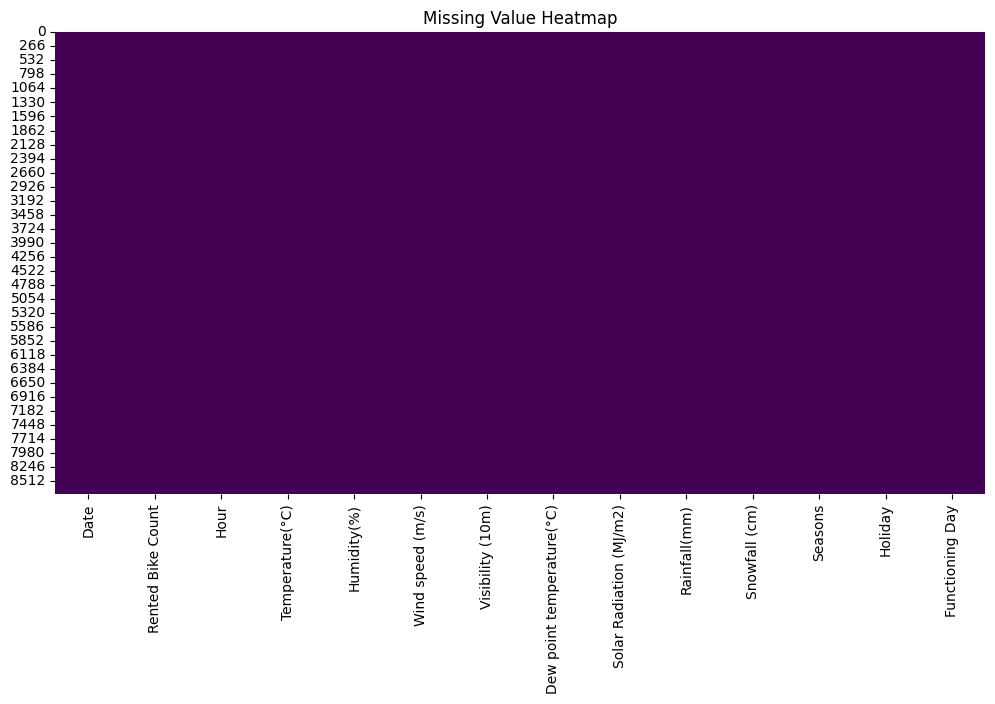

In [4]:
# =========================
# 2. MISSING VALUE ANALYSIS and Fix
# =========================

missing_values = df.isnull().sum()

missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame(
    {"Missing Values": missing_values, "Percentage": missing_percent}
)

print(missing_df)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

# Filling not needed as there are no missing values in the dataset
# df.interpolate(method='linear', inplace=True)
# Or
# df.fillna(method='ffill', inplace=True)

In [5]:
# =========================
# 3. DUPLICATE CHECK
# =========================

print("Duplicate Rows:", df.duplicated().sum())

# Create full timestamp
df["Datetime"] = df["Date"] + pd.to_timedelta(df["Hour"], unit="h")

duplicate_timestamps = df["Datetime"].duplicated().sum()

print("Duplicate Timestamps:", duplicate_timestamps)

Duplicate Rows: 0
Duplicate Timestamps: 0


In [6]:
# =========================
# 4. DATA TYPE FIXES
# =========================

# Convert categorical text to category type

categorical_cols = ["Seasons", "Holiday", "Functioning Day"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print(df.dtypes)

# Season Encoding

season_mapping = {"Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 3}

df["Seasons"] = df["Seasons"].map(season_mapping)

# Holiday Encoding

holiday_mapping = {"No Holiday": 0, "Holiday": 1}

df["Holiday"] = df["Holiday"].map(holiday_mapping)

# Functioning Day Encoding

func_mapping = {"No": 0, "Yes": 1}

df["Functioning Day"] = df["Functioning Day"].map(func_mapping)

Date                         datetime64[us]
Rented Bike Count                     int64
Hour                                  int64
Temperature(°C)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(°C)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                            category
Holiday                            category
Functioning Day                    category
Datetime                     datetime64[us]
dtype: object


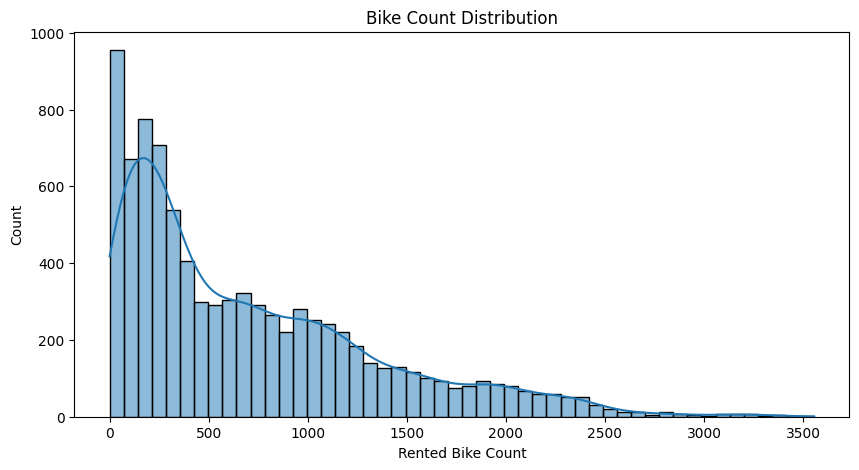

Zero Demand Hours: 295


In [7]:
# =========================
# 5. TARGET VARIABLE ANALYSIS
# =========================

target = "Rented Bike Count"

plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=50, kde=True)
plt.title("Bike Count Distribution")
plt.show()

zero_counts = (df[target] == 0).sum()

print("Zero Demand Hours:", zero_counts)

(8465, 15)


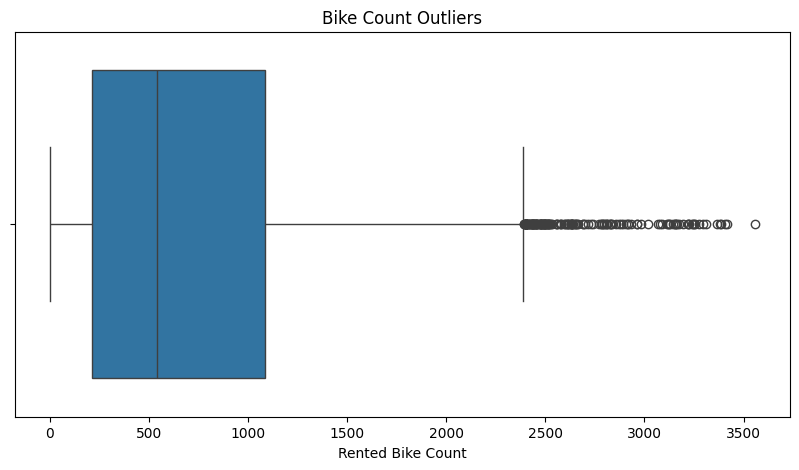

In [8]:
# remove non-functioning days
df = df[df["Functioning Day"] == 1]
print(df.shape)

# Check for outliers using boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df[target])
plt.title("Bike Count Outliers")
plt.show()

# Cap outliers at 99th percentile
upper_limit = df[target].quantile(0.99)

df[target] = np.where(df[target] > upper_limit, upper_limit, df[target])

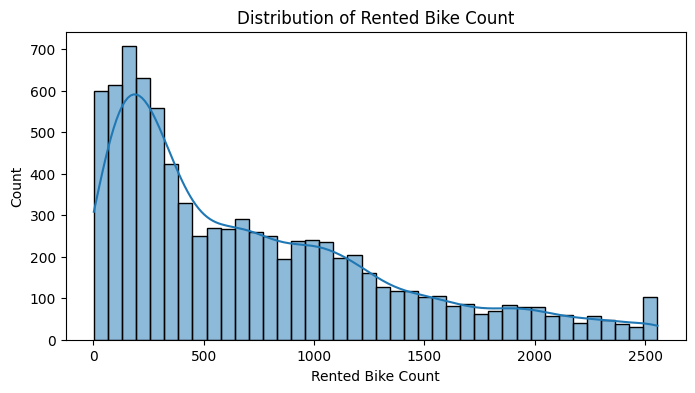

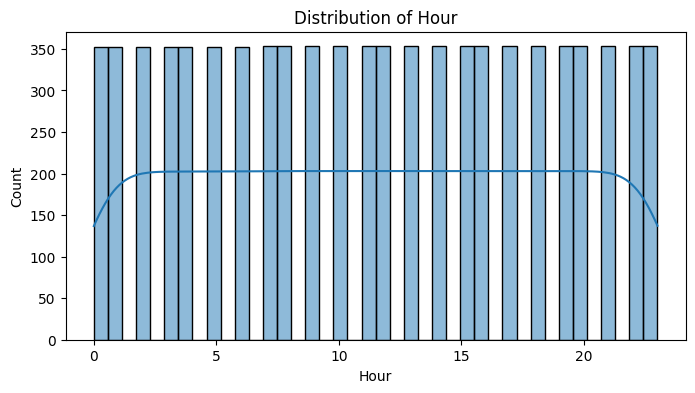

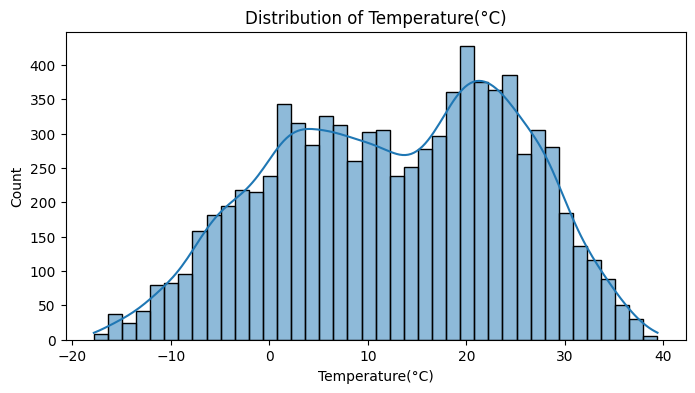

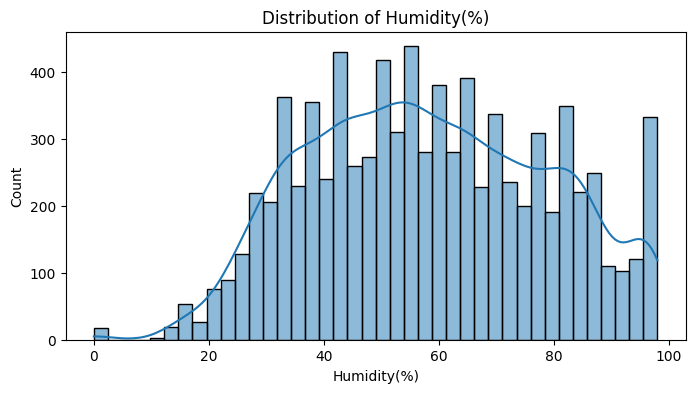

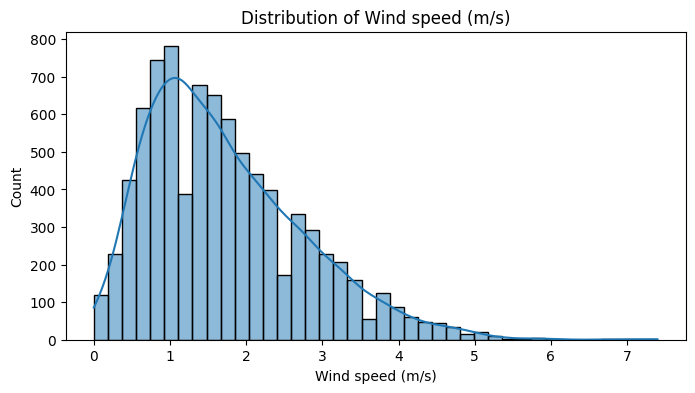

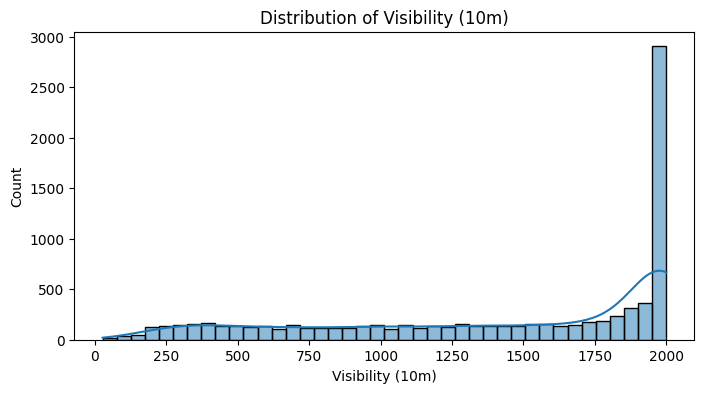

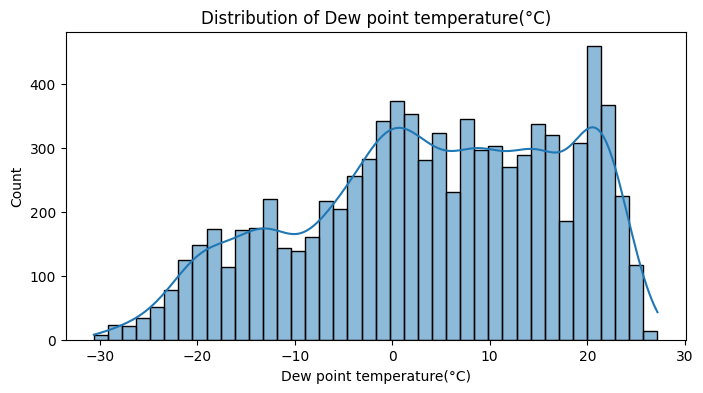

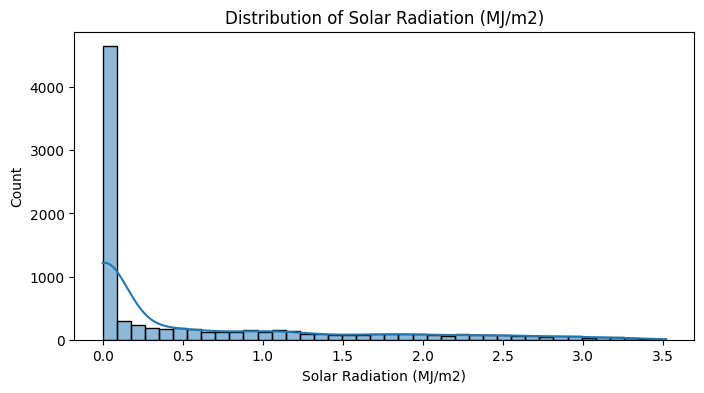

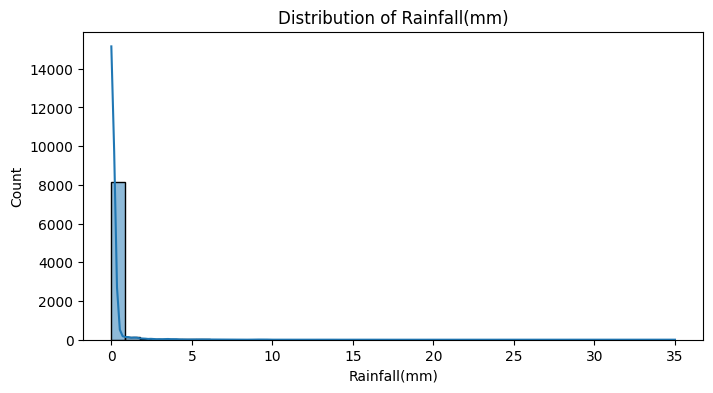

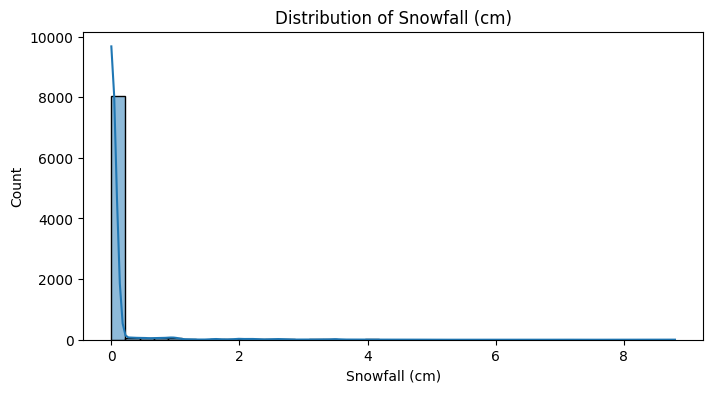

In [9]:
# =========================
# 6. FEATURE DISTRIBUTIONS
# =========================

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(df[col], kde=True, bins=40)

    plt.title(f"Distribution of {col}")

    plt.show()

# Log-transform skewed features
skewed_cols = ["Rainfall(mm)", "Snowfall (cm)"]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

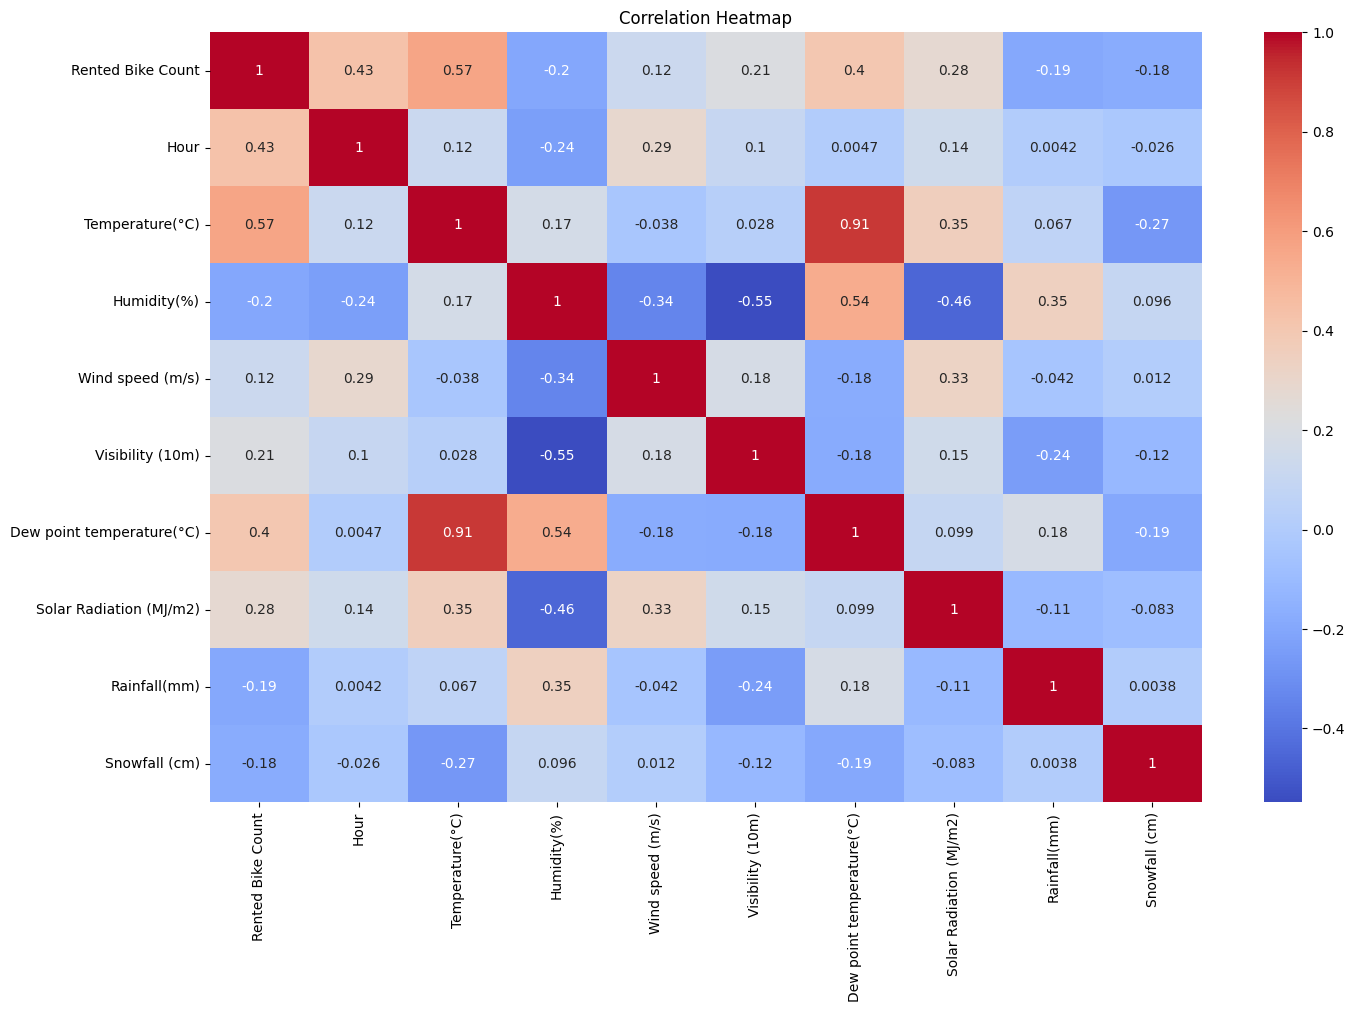

Highly Correlated Features:
['Dew point temperature(°C)']


In [10]:
# =========================
# 7. CORRELATION ANALYSIS
# =========================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 10))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Identify highly correlated features (threshold > 0.90)
corr_matrix = corr.abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column] > 0.90)]

print("Highly Correlated Features:")
print(high_corr)

# drop highly correlated features

df.drop(columns=["Dew point temperature(°C)"], inplace=True)

In [11]:
# =========================
# 8. TEMPORAL CONTINUITY
# =========================

print("Total Rows:", len(df))
expected_rows = 365 * 24
print("Expected Rows:", expected_rows)

Total Rows: 8465
Expected Rows: 8760


Missing Hours: 295


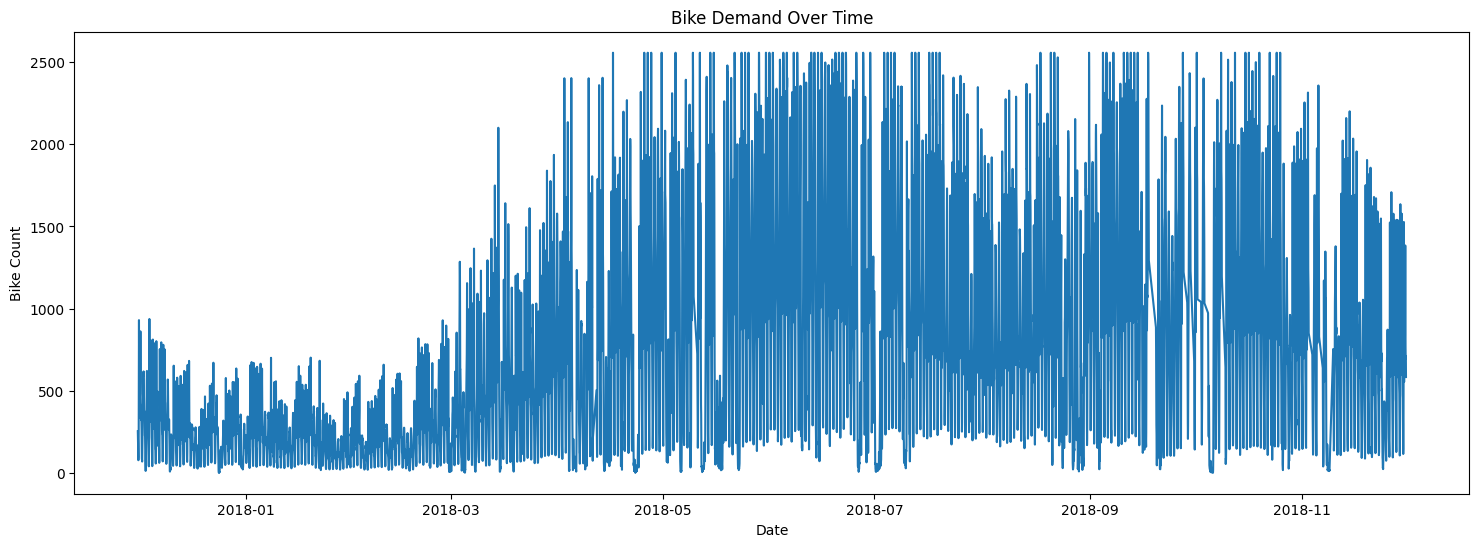

In [12]:
full_range = pd.date_range(
    start=df["Datetime"].min(), end=df["Datetime"].max(), freq="h"
)

missing_hours = full_range.difference(df["Datetime"])

print("Missing Hours:", len(missing_hours))

plt.figure(figsize=(18, 6))

plt.plot(df["Datetime"], df["Rented Bike Count"])

plt.title("Bike Demand Over Time")

plt.xlabel("Date")

plt.ylabel("Bike Count")

plt.show()

In [13]:
# =========================
# 9. FEATURE ENGINEERING
# =========================

df["day_of_week"] = df["Date"].dt.dayofweek

df["month"] = df["Date"].dt.month

df["is_weekend"] = np.where(df["day_of_week"] >= 5, 1, 0)

# Peak hours: 7-9 AM and 5-8 PM
peak_hours = [7, 8, 9, 17, 18, 19, 20]

df["is_peak_hour"] = np.where(df["Hour"].isin(peak_hours), 1, 0)

# Hour cyclic encoding

df["hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)

df["hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

# Month cyclic encoding

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)

df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Weather severity index (simple sum of weather factors)
df["weather_severity"] = (
    df["Rainfall(mm)"] + df["Snowfall (cm)"] + (100 - df["Visibility (10m)"]) / 100
)

# Lag features
df["lag_1h"] = df["Rented Bike Count"].shift(1)

df["lag_24h"] = df["Rented Bike Count"].shift(24)

df["lag_168h"] = df["Rented Bike Count"].shift(168)

# Rolling mean features
df["rolling_mean_3h"] = df["Rented Bike Count"].rolling(window=3).mean()

df["rolling_mean_24h"] = df["Rented Bike Count"].rolling(window=24).mean()

# After feature engineering, drop rows with NaN values created by lag/rolling features
df.dropna(inplace=True)
# Reset index so row positions 0..N-1 match .iloc and time-based splits
df.reset_index(drop=True, inplace=True)

print(df.shape)

(8297, 28)


In [14]:
# =========================
# 11. TRAIN TEST SPLIT
# =========================

target_col = "Rented Bike Count"

features = df.drop(columns=[target_col, "Date", "Datetime"])

target = df[target_col]

# Since this is time series data, we will do a temporal split instead of random split
train_size = int(len(df) * 0.70)

val_size = int(len(df) * 0.15)

X_train = features[:train_size]

y_train = target[:train_size]

X_val = features[train_size : train_size + val_size]

y_val = target[train_size : train_size + val_size]

X_test = features[train_size + val_size :]

y_test = target[train_size + val_size :]

In [15]:
# =========================
# 12. SCALING
# =========================

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

# Fit scalers on training data
X_train_scaled = feature_scaler.fit_transform(X_train)

X_val_scaled = feature_scaler.transform(X_val)

X_test_scaled = feature_scaler.transform(X_test)

# Scale target variable
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))

y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1))

y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

In [16]:
# =========================
# 13. SEQUENCE CREATION
# =========================


def create_sequences(X, y, window_size=24):

    Xs = []
    ys = []

    for i in range(len(X) - window_size):

        Xs.append(X[i : i + window_size])

        ys.append(y[i + window_size])

    return np.array(Xs), np.array(ys)


# build sequences with 24-hour window
window_size = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)

X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, window_size)

X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)

print(X_train_seq.shape)
print(y_train_seq.shape)

print(X_val_seq.shape)
print(y_val_seq.shape)

print(X_test_seq.shape)
print(y_test_seq.shape)

(5783, 24, 25)
(5783, 1)
(1220, 24, 25)
(1220, 1)
(1222, 24, 25)
(1222, 1)


In [17]:
# =========================
# 14. FINAL SANITY CHECKS
# =========================

print("Train Min:", X_train_seq.min())
print("Train Max:", X_train_seq.max())

print("Validation Min:", X_val_seq.min())
print("Validation Max:", X_val_seq.max())

print("Test Min:", X_test_seq.min())
print("Test Max:", X_test_seq.max())

# # Visualize one input sequence
# sample_sequence = X_train_seq[0][:, 0]

# print("Sample Sequence (first feature):", sample_sequence)

Train Min: 0.0
Train Max: 1.0
Validation Min: -0.071796769724491
Validation Max: 1.5
Test Min: -1.6653345369377348e-16
Test Max: 1.5


##### Phase 5–8: Model training, evaluation, and comparison
###### The cells below continue after preprocessing/sequence creation. They train multiple deep learning architectures and compare them using original-scale metrics (RMSE, MAE, MAPE).

In [18]:
# =========================
# 15. MODELING IMPORTS
# =========================

import os
import time
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional: only needed for Phase 8
import keras_tuner as kt

In [19]:
# =========================
# 16. REPRODUCIBILITY
# =========================

SEED = 42

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    # Not supported on all platforms / TF builds
    pass

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)

TensorFlow: 2.21.0
Seed: 42


In [20]:
# =========================
# 17. METRICS + EVALUATION HELPERS (original-scale)
# =========================

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def _to_1d(x):
    x = tf.convert_to_tensor(x)
    x = tf.reshape(x, [-1])
    return x.numpy()


def inverse_scale_target(y_scaled, target_scaler):
    """Inverse-transform scaled y back to original bike-count scale."""
    y_scaled = _to_1d(y_scaled)
    y_scaled = y_scaled.reshape(-1, 1)
    return target_scaler.inverse_transform(y_scaled).reshape(-1)


def rmse(y_true, y_pred):
    # Compatible with older/newer scikit-learn versions
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps=1e-6):
    y_true = y_true.astype("float64")
    y_pred = y_pred.astype("float64")
    denom = (abs(y_true) + eps)
    return float((abs((y_true - y_pred) / denom)).mean() * 100.0)


def smape(y_true, y_pred, eps=1e-6):
    y_true = y_true.astype("float64")
    y_pred = y_pred.astype("float64")
    denom = (abs(y_true) + abs(y_pred) + eps)
    return float((2.0 * abs(y_pred - y_true) / denom).mean() * 100.0)


def evaluate_1step_model(
    model,
    X_seq,
    y_seq_scaled,
    target_scaler,
    model_name,
    batch_size=256,
):
    """Evaluate a 1-step forecasting model on (X_seq, y_seq_scaled)."""

    t0 = time.time()
    y_pred_scaled = model.predict(X_seq, batch_size=batch_size, verbose=0)
    infer_s = time.time() - t0

    y_true = inverse_scale_target(y_seq_scaled, target_scaler)
    y_pred = inverse_scale_target(y_pred_scaled, target_scaler)

    metrics = {
        "model": model_name,
        "task": "1step",
        "n_samples": int(len(y_true)),
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "r2": float(r2_score(y_true, y_pred)),
        "inference_seconds": float(infer_s),
    }
    return metrics


def predict_1step_original_scale(model, X_seq, y_seq_scaled, target_scaler, batch_size=256):
    """Return (y_true, y_pred) in original bike-count units."""
    y_pred_scaled = model.predict(X_seq, batch_size=batch_size, verbose=0)
    y_true = inverse_scale_target(y_seq_scaled, target_scaler)
    y_pred = inverse_scale_target(y_pred_scaled, target_scaler)
    return y_true, y_pred


# --- Regression diagnostics (loss curves, pred vs actual, binned confusion matrix) ---
PLOTS_DIR = ARTIFACT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_MATRICES_DIR = ARTIFACT_DIR / "confusion_matrices"
CONFUSION_MATRICES_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_MATRIX_REGISTRY = CONFUSION_MATRICES_DIR / "registry.json"
SAVE_DIAGNOSTIC_PLOTS = True
SHOW_DIAGNOSTIC_PLOTS = False
N_DEMAND_BINS = 5
TRAINING_HISTORIES = {}


def fit_demand_bin_edges(y_train_original, n_bins=N_DEMAND_BINS):
    """Quantile bins on training demand (for classification-style confusion matrix)."""
    y = np.asarray(y_train_original, dtype=float)
    edges = np.unique(np.quantile(y, np.linspace(0.0, 1.0, n_bins + 1)))
    if len(edges) < 3:
        edges = np.linspace(y.min(), y.max(), n_bins + 1)
    edges[0] -= 1e-6
    edges[-1] += 1e-6
    return edges


def assign_demand_bin_indices(y, bin_edges):
    return np.clip(np.digitize(np.asarray(y, dtype=float), bin_edges[1:-1]), 0, len(bin_edges) - 2)


def _bin_tick_labels(bin_edges):
    labels = []
    for i in range(len(bin_edges) - 1):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        labels.append(f"{lo:.0f}–{hi:.0f}")
    return labels


def _maybe_show_and_save(fig, out_path):
    fig.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    if SHOW_DIAGNOSTIC_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def plot_learning_curves(history, run_name, out_dir):
    h = history.history
    if "loss" not in h:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(h["loss"], label="train loss (MSE, scaled target)")
    if "val_loss" in h:
        ax.plot(h["val_loss"], label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(f"Training curve — {run_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    _maybe_show_and_save(fig, out_dir / "learning_curve.png")


def plot_pred_vs_actual(y_true, y_pred, title, out_path, max_points=2500):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    if n > max_points:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, size=max_points, replace=False)
        y_true, y_pred = y_true[idx], y_pred[idx]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.35, s=12, edgecolors="none")
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="perfect prediction")
    ax.set_xlabel("Actual bikes")
    ax.set_ylabel("Predicted bikes")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    _maybe_show_and_save(fig, out_path)


def plot_residuals(y_true, y_pred, title, out_path, max_points=2500):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    resid = y_true - y_pred
    n = len(y_true)
    if n > max_points:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, size=max_points, replace=False)
        y_pred, resid = y_pred[idx], resid[idx]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(y_pred, resid, alpha=0.35, s=12, edgecolors="none")
    ax.axhline(0, color="r", linestyle="--", lw=1)
    ax.set_xlabel("Predicted bikes")
    ax.set_ylabel("Residual (actual − predicted)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    _maybe_show_and_save(fig, out_path)


def compute_binned_confusion_payload(y_true, y_pred, bin_edges, run_name, split):
    """Build CM array + metadata for plots and report (JSON)."""
    from sklearn.metrics import confusion_matrix

    true_idx = assign_demand_bin_indices(y_true, bin_edges)
    pred_idx = assign_demand_bin_indices(y_pred, bin_edges)
    n_cls = len(bin_edges) - 1
    labels = list(range(n_cls))
    cm = confusion_matrix(true_idx, pred_idx, labels=labels)
    bin_labels = _bin_tick_labels(bin_edges)
    total = int(cm.sum())
    bin_accuracy = float(np.trace(cm) / total) if total > 0 else None
    png_rel = PLOTS_DIR / run_name / f"confusion_matrix_binned_{split}.png"
    return {
        "model": run_name,
        "split": split,
        "task": "1step_binned_confusion",
        "n_samples": int(len(y_true)),
        "n_bins": int(n_cls),
        "bin_edges": [float(x) for x in bin_edges],
        "bin_labels": bin_labels,
        "matrix": cm.astype(int).tolist(),
        "bin_accuracy": bin_accuracy,
        "png_path": str(png_rel),
    }


def save_confusion_matrix_artifact(payload):
    """Persist CM JSON under artifacts/confusion_matrices/ and update registry."""
    import json
    from datetime import datetime, timezone

    run_name = payload["model"]
    split = payload["split"]
    out_path = CONFUSION_MATRICES_DIR / f"{run_name}__{split}.json"
    record = dict(payload)
    record["json_path"] = str(out_path)
    record["saved_at"] = datetime.now(timezone.utc).isoformat()
    out_path.write_text(json.dumps(record, indent=2))

    registry = {"models": [], "updated_at": record["saved_at"]}
    if CONFUSION_MATRIX_REGISTRY.exists():
        registry = json.loads(CONFUSION_MATRIX_REGISTRY.read_text())
    registry["models"] = [
        e
        for e in registry.get("models", [])
        if not (e.get("model") == run_name and e.get("split") == split)
    ]
    registry["models"].append(
        {
            "model": run_name,
            "split": split,
            "json_path": str(out_path),
            "png_path": record.get("png_path"),
            "n_samples": record.get("n_samples"),
            "bin_accuracy": record.get("bin_accuracy"),
        }
    )
    registry["updated_at"] = record["saved_at"]
    CONFUSION_MATRIX_REGISTRY.write_text(json.dumps(registry, indent=2))
    return out_path


def plot_binned_confusion_matrix(payload, title, out_path):
    cm = np.asarray(payload["matrix"], dtype=int)
    tick = payload["bin_labels"]
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=tick,
        yticklabels=tick,
        ax=ax,
    )
    ax.set_xlabel("Predicted demand bin")
    ax.set_ylabel("Actual demand bin")
    ax.set_title(title + "\n(binned regression — not class labels)")
    _maybe_show_and_save(fig, out_path)


def plot_binned_confusion_matrix_from_arrays(y_true, y_pred, bin_edges, run_name, split, title, out_path):
    payload = compute_binned_confusion_payload(y_true, y_pred, bin_edges, run_name, split)
    save_confusion_matrix_artifact(payload)
    plot_binned_confusion_matrix(payload, title, out_path)
    return payload


def save_1step_model_diagnostics(
    run_name,
    model,
    ds,
    history=None,
    batch_size=256,
    splits=("val", "test"),
):
    """Save loss curve, pred-vs-actual, residuals, and binned CM per split."""
    out_dir = PLOTS_DIR / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    import json

    y_train = inverse_scale_target(ds["y_train_seq"], ds["target_scaler"])
    bin_edges = fit_demand_bin_edges(y_train)
    (out_dir / "demand_bin_edges.json").write_text(
        json.dumps(
            {
                "model": run_name,
                "n_bins": int(len(bin_edges) - 1),
                "bin_edges": [float(x) for x in bin_edges],
                "bin_labels": _bin_tick_labels(bin_edges),
            },
            indent=2,
        )
    )

    if history is not None:
        plot_learning_curves(history, run_name, out_dir)

    for split in splits:
        x_key, y_key = f"X_{split}_seq", f"y_{split}_seq"
        if x_key not in ds:
            continue
        y_true, y_pred = predict_1step_original_scale(
            model, ds[x_key], ds[y_key], ds["target_scaler"], batch_size=batch_size
        )
        tag = split
        plot_pred_vs_actual(
            y_true,
            y_pred,
            f"{run_name} — {tag}: predicted vs actual",
            out_dir / f"pred_vs_actual_{tag}.png",
        )
        plot_residuals(
            y_true,
            y_pred,
            f"{run_name} — {tag}: residuals",
            out_dir / f"residuals_{tag}.png",
        )
        plot_binned_confusion_matrix_from_arrays(
            y_true,
            y_pred,
            bin_edges,
            run_name,
            tag,
            f"{run_name} — {tag}: demand bins",
            out_dir / f"confusion_matrix_binned_{tag}.png",
        )

    print(f"Diagnostics saved → {out_dir.resolve()}")
    print(f"Confusion matrices (JSON) → {CONFUSION_MATRICES_DIR.resolve()}")
    print(f"Registry → {CONFUSION_MATRIX_REGISTRY.resolve()}")


RESULTS = []
print("Artifact dir:", ARTIFACT_DIR.resolve())
print("Diagnostic plots →", PLOTS_DIR.resolve())
print("Confusion matrix JSON →", CONFUSION_MATRICES_DIR.resolve())

Artifact dir: /Users/rohit/Desktop/uni/dl-final-project/artifacts
Diagnostic plots → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots
Confusion matrix JSON → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices


##### Phase 3 (Ablation): Raw weather vs `weather_severity`

###### This section builds two parallel modeling datasets: - **Raw weather**: keeps `Rainfall(mm)`, `Snowfall (cm)`,`Visibility (10m)` and drops `weather_severity`.
###### - **Severity index**: keeps `weather_severity` and drops `Rainfall(mm)`, `Snowfall (cm)`, `Visibility (10m)`.

###### All other engineered features stay the same, and the split remains chronological (70/15/15).

In [21]:
# =========================
# 18. BUILD TWO FEATURE-VARIANT DATASETS + SEQUENCES
# =========================

RAW_WEATHER_COLS = ["Rainfall(mm)", "Snowfall (cm)", "Visibility (10m)"]
SEVERITY_COL = "weather_severity"

# Sanity: confirm columns exist
for c in RAW_WEATHER_COLS + [SEVERITY_COL]:
    if c not in df.columns:
        raise ValueError(f"Missing expected column: {c}")

base_feature_cols = [c for c in df.columns if c not in [target_col, "Date", "Datetime"]]

raw_variant_cols = [c for c in base_feature_cols if c != SEVERITY_COL]
severity_variant_cols = [c for c in base_feature_cols if c not in RAW_WEATHER_COLS]

print("Base feature count:", len(base_feature_cols))
print("Raw-weather feature count:", len(raw_variant_cols))
print("Severity-index feature count:", len(severity_variant_cols))


def build_sequences_for_feature_cols(feature_cols, window_size=24):
    features_v = df[feature_cols]
    target_v = df[target_col]

    train_size = int(len(df) * 0.70)
    val_size = int(len(df) * 0.15)

    X_train_v = features_v[:train_size]
    y_train_v = target_v[:train_size]

    X_val_v = features_v[train_size : train_size + val_size]
    y_val_v = target_v[train_size : train_size + val_size]

    X_test_v = features_v[train_size + val_size :]
    y_test_v = target_v[train_size + val_size :]

    feature_scaler_v = MinMaxScaler()

    X_train_scaled_v = feature_scaler_v.fit_transform(X_train_v)
    X_val_scaled_v = feature_scaler_v.transform(X_val_v)
    X_test_scaled_v = feature_scaler_v.transform(X_test_v)

    # Use a fresh target scaler per variant (fit on the same y_train split).
    # This keeps the pipeline self-contained and avoids accidental reuse.
    target_scaler_v = MinMaxScaler()
    y_train_scaled_v = target_scaler_v.fit_transform(y_train_v.values.reshape(-1, 1))
    y_val_scaled_v = target_scaler_v.transform(y_val_v.values.reshape(-1, 1))
    y_test_scaled_v = target_scaler_v.transform(y_test_v.values.reshape(-1, 1))

    X_train_seq_v, y_train_seq_v = create_sequences(X_train_scaled_v, y_train_scaled_v, window_size)
    X_val_seq_v, y_val_seq_v = create_sequences(X_val_scaled_v, y_val_scaled_v, window_size)
    X_test_seq_v, y_test_seq_v = create_sequences(X_test_scaled_v, y_test_scaled_v, window_size)

    return {
        "feature_cols": feature_cols,
        "feature_scaler": feature_scaler_v,
        "target_scaler": target_scaler_v,
        "X_train_seq": X_train_seq_v,
        "y_train_seq": y_train_seq_v,
        "X_val_seq": X_val_seq_v,
        "y_val_seq": y_val_seq_v,
        "X_test_seq": X_test_seq_v,
        "y_test_seq": y_test_seq_v,
    }


WINDOW_SIZE = 24

datasets = {
    "raw_weather": build_sequences_for_feature_cols(raw_variant_cols, window_size=WINDOW_SIZE),
    "severity_index": build_sequences_for_feature_cols(severity_variant_cols, window_size=WINDOW_SIZE),
}

for name, ds in datasets.items():
    print("\n===", name, "===")
    print("n_features:", ds["X_train_seq"].shape[-1])
    print("train:", ds["X_train_seq"].shape, ds["y_train_seq"].shape)
    print("val  :", ds["X_val_seq"].shape, ds["y_val_seq"].shape)
    print("test :", ds["X_test_seq"].shape, ds["y_test_seq"].shape)

Base feature count: 25
Raw-weather feature count: 24
Severity-index feature count: 22

=== raw_weather ===
n_features: 24
train: (5783, 24, 24) (5783, 1)
val  : (1220, 24, 24) (1220, 1)
test : (1222, 24, 24) (1222, 1)

=== severity_index ===
n_features: 22
train: (5783, 24, 22) (5783, 1)
val  : (1220, 24, 22) (1220, 1)
test : (1222, 24, 22) (1222, 1)


##### Phase 5: Baseline model family (Vanilla LSTM, BiLSTM, CNN-LSTM)

###### Each model is trained on both feature variants (`raw_weather`, `severity_index`) using the same training settings and then evaluated on the test split in original bike-count scale.

In [22]:
# =========================
# 19. TRAINING UTILITIES
# =========================

EPOCHS = 50
BATCH_SIZE = 256


def make_callbacks(run_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(ARTIFACT_DIR / f"{run_name}.keras"),
            monitor="val_loss",
            save_best_only=True,
        ),
    ]


def train_and_evaluate_1step(
    run_name,
    model,
    ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
):
    history = model.fit(
        ds["X_train_seq"],
        ds["y_train_seq"],
        validation_data=(ds["X_val_seq"], ds["y_val_seq"]),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=make_callbacks(run_name),
        verbose=1,
    )
    TRAINING_HISTORIES[run_name] = history

    if SAVE_DIAGNOSTIC_PLOTS:
        save_1step_model_diagnostics(
            run_name, model, ds, history=history, batch_size=batch_size
        )

    test_metrics = evaluate_1step_model(
        model=model,
        X_seq=ds["X_test_seq"],
        y_seq_scaled=ds["y_test_seq"],
        target_scaler=ds["target_scaler"],
        model_name=run_name,
        batch_size=batch_size,
    )

    # Optional: also track validation metrics in original scale
    val_metrics = evaluate_1step_model(
        model=model,
        X_seq=ds["X_val_seq"],
        y_seq_scaled=ds["y_val_seq"],
        target_scaler=ds["target_scaler"],
        model_name=run_name,
        batch_size=batch_size,
    )
    val_metrics["split"] = "val"

    test_metrics["split"] = "test"

    RESULTS.append(val_metrics)
    RESULTS.append(test_metrics)

    return history, val_metrics, test_metrics

In [23]:
# =========================
# 20. VANILLA LSTM (baseline)
# =========================


def build_vanilla_lstm(input_shape, lstm_units=64, dropout=0.2):
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(lstm_units, dropout=dropout)(inputs)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs, name="vanilla_lstm")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )
    return model


for variant_name, ds in datasets.items():
    run_name = f"vanilla_lstm__{variant_name}"
    model = build_vanilla_lstm(input_shape=ds["X_train_seq"].shape[1:])
    print("\nTraining:", run_name)
    _hist, _val_m, _test_m = train_and_evaluate_1step(run_name, model, ds)
    print("VAL :", {k: _val_m[k] for k in ["rmse", "mae", "mape", "smape"]})
    print("TEST:", {k: _test_m[k] for k in ["rmse", "mae", "mape", "smape"]})


Training: vanilla_lstm__raw_weather
Epoch 1/50


E0000 00:00:1780409453.286000   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0410 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0212 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0184 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0173 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0172 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0158 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0148 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0146 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0146 - val_loss: 0.0173 - learning_rate: 0.0010
Epoch 10/50
23/23 ━━━━━━━━━━━━

E0000 00:00:1780409461.110933   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/vanilla_lstm__raw_weather
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json
VAL : {'rmse': 324.84895587924115, 'mae': 241.65031902039638, 'mape': 78.0755511031652, 'smape': 34.687203696734535}
TEST: {'rmse': 303.01063082515094, 'mae': 215.29146099159254, 'mape': 57.28736977062175, 'smape': 32.2887403265158}

Training: vanilla_lstm__severity_index
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0409 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0223 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0195 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0180 - val_loss: 0.0226 - learning_rate:

E0000 00:00:1780409470.509371   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/vanilla_lstm__severity_index
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json
VAL : {'rmse': 324.7404140431448, 'mae': 245.59324344525572, 'mape': 94.81830704956714, 'smape': 34.31919545110355}
TEST: {'rmse': 294.06841862799683, 'mae': 220.3584511524956, 'mape': 63.61638187803976, 'smape': 33.75288082166918}


In [24]:
# =========================
# 21. BIDIRECTIONAL LSTM
# =========================


def build_bilstm(input_shape, lstm_units=64, dropout=0.2):
    inputs = keras.Input(shape=input_shape)
    x = layers.Bidirectional(layers.LSTM(lstm_units, dropout=dropout))(inputs)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs, name="bilstm")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )
    return model


for variant_name, ds in datasets.items():
    run_name = f"bilstm__{variant_name}"
    model = build_bilstm(input_shape=ds["X_train_seq"].shape[1:])
    print("\nTraining:", run_name)
    _hist, _val_m, _test_m = train_and_evaluate_1step(run_name, model, ds)
    print("VAL :", {k: _val_m[k] for k in ["rmse", "mae", "mape", "smape"]})
    print("TEST:", {k: _test_m[k] for k in ["rmse", "mae", "mape", "smape"]})


Training: bilstm__raw_weather
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0500 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0213 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0171 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0155 - val_loss: 0.0185 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0147 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0142 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0134 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0130 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0129 - val_loss: 0.0167 - learning_r

E0000 00:00:1780409483.662296   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/bilstm__raw_weather
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json
VAL : {'rmse': 319.3407051094687, 'mae': 232.02701654387303, 'mape': 78.84391929543779, 'smape': 32.99345078697513}
TEST: {'rmse': 294.075294036292, 'mae': 202.43178104213334, 'mape': 56.76782638387132, 'smape': 30.52496210341718}

Training: bilstm__severity_index
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0440 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0204 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0177 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0156 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 

E0000 00:00:1780409504.664266   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/bilstm__severity_index
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json
VAL : {'rmse': 315.4571442255184, 'mae': 237.0193953610053, 'mape': 80.31245485158736, 'smape': 32.36999916739754}
TEST: {'rmse': 304.6332668935867, 'mae': 220.2232963877926, 'mape': 56.165712200756836, 'smape': 32.08844963661582}


In [25]:
# =========================
# 22. CNN-LSTM
# =========================


def build_cnn_lstm(
    input_shape,
    conv_filters=64,
    kernel_size=3,
    lstm_units=64,
    dropout=0.2,
):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal")(inputs)
    x = layers.ReLU()(x)
    x = layers.MaxPool1D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)

    x = layers.LSTM(lstm_units, dropout=dropout)(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs, name="cnn_lstm")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )
    return model


for variant_name, ds in datasets.items():
    run_name = f"cnn_lstm__{variant_name}"
    model = build_cnn_lstm(input_shape=ds["X_train_seq"].shape[1:])
    print("\nTraining:", run_name)
    _hist, _val_m, _test_m = train_and_evaluate_1step(run_name, model, ds)
    print("VAL :", {k: _val_m[k] for k in ["rmse", "mae", "mape", "smape"]})
    print("TEST:", {k: _test_m[k] for k in ["rmse", "mae", "mape", "smape"]})


Training: cnn_lstm__raw_weather
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0764 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0313 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0235 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0198 - val_loss: 0.0255 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0179 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0162 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0152 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0142 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0133 - val_loss: 0.0200 - learning

E0000 00:00:1780409518.887947   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/cnn_lstm__raw_weather
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json
VAL : {'rmse': 290.62856715239894, 'mae': 215.87906378734309, 'mape': 73.38189777085103, 'smape': 32.068712725816646}
TEST: {'rmse': 263.9642734834735, 'mae': 190.14807973858572, 'mape': 60.480782787145806, 'smape': 30.45690780823448}

Training: cnn_lstm__severity_index
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0603 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0306 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0228 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0191 - val_loss: 0.0275 - learning_rate: 0.001

E0000 00:00:1780409530.039641   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/cnn_lstm__severity_index
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json
VAL : {'rmse': 312.86819830835515, 'mae': 232.2066179739843, 'mape': 82.35912381503519, 'smape': 33.78199000087573}
TEST: {'rmse': 306.4490742150867, 'mae': 216.5166761011851, 'mape': 58.661985434699346, 'smape': 32.556843919957316}


##### Phase 4 + Phase 6: Peak/off-peak specialists + Attention

###### - **Specialists**: train separate models for peak vs off-peak hours (07–09 and 17–20) using the same sequence tensors, filtered by the *target hour*.
###### - **Attention**: train a CNN-LSTM with temporal attention and visualize attention weights over the 24-hour input window.

In [26]:
# =========================
# 23. PEAK / OFF-PEAK MASKS (aligned to the target timestep)
# =========================

# Target labels in create_sequences correspond to index (i + WINDOW_SIZE) within each split.
# Build boolean masks using df["is_peak_hour"] at those target indices.

peak_hours = [7, 8, 9, 17, 18, 19, 20]

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_start, train_end = 0, train_size
val_start, val_end = train_end, train_end + val_size
test_start, test_end = val_end, len(df)


def target_index_range(split_start, split_end, window_size=WINDOW_SIZE):
    # targets are at positions [split_start + window_size, ..., split_end - 1]
    return np.arange(split_start + window_size, split_end)


def make_peak_mask(split_start, split_end, window_size=WINDOW_SIZE):
    tgt_idx = target_index_range(split_start, split_end, window_size)
    # tgt_idx are row *positions* (0..len-1); after dropna() index labels may be non-contiguous
    return df.iloc[tgt_idx]["Hour"].isin(peak_hours).to_numpy()


def subset_by_mask(X_seq, y_seq, mask):
    return X_seq[mask], y_seq[mask]


masks = {
    "train_peak": make_peak_mask(train_start, train_end),
    "val_peak": make_peak_mask(val_start, val_end),
    "test_peak": make_peak_mask(test_start, test_end),
}

masks["train_offpeak"] = ~masks["train_peak"]
masks["val_offpeak"] = ~masks["val_peak"]
masks["test_offpeak"] = ~masks["test_peak"]

for k, v in masks.items():
    print(k, "count=", int(v.sum()), "/", len(v))

train_peak count= 1687 / 5783
val_peak count= 355 / 1220
test_peak count= 357 / 1222
train_offpeak count= 4096 / 5783
val_offpeak count= 865 / 1220
test_offpeak count= 865 / 1222


In [27]:
# =========================
# 24. PEAK / OFF-PEAK SPECIALIST TRAINING (using CNN-LSTM)
# =========================

# You can switch `build_cnn_lstm` to whichever architecture performed best in Phase 5.

for variant_name, ds in datasets.items():
    # Train peak specialist
    X_train_peak, y_train_peak = subset_by_mask(ds["X_train_seq"], ds["y_train_seq"], masks["train_peak"])
    X_val_peak, y_val_peak = subset_by_mask(ds["X_val_seq"], ds["y_val_seq"], masks["val_peak"])
    X_test_peak, y_test_peak = subset_by_mask(ds["X_test_seq"], ds["y_test_seq"], masks["test_peak"])

    run_name_peak = f"cnn_lstm_peak_specialist__{variant_name}"
    model_peak = build_cnn_lstm(input_shape=ds["X_train_seq"].shape[1:])

    print("\nTraining:", run_name_peak)
    model_peak.fit(
        X_train_peak,
        y_train_peak,
        validation_data=(X_val_peak, y_val_peak),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(run_name_peak),
        verbose=1,
    )

    peak_test_metrics = evaluate_1step_model(
        model=model_peak,
        X_seq=X_test_peak,
        y_seq_scaled=y_test_peak,
        target_scaler=ds["target_scaler"],
        model_name=run_name_peak,
        batch_size=BATCH_SIZE,
    )
    peak_test_metrics["split"] = "test_peak_only"
    RESULTS.append(peak_test_metrics)
    print("TEST (peak-only):", {k: peak_test_metrics[k] for k in ["rmse", "mae", "mape", "smape"]})

    # Train off-peak specialist
    X_train_off, y_train_off = subset_by_mask(ds["X_train_seq"], ds["y_train_seq"], masks["train_offpeak"])
    X_val_off, y_val_off = subset_by_mask(ds["X_val_seq"], ds["y_val_seq"], masks["val_offpeak"])
    X_test_off, y_test_off = subset_by_mask(ds["X_test_seq"], ds["y_test_seq"], masks["test_offpeak"])

    run_name_off = f"cnn_lstm_offpeak_specialist__{variant_name}"
    model_off = build_cnn_lstm(input_shape=ds["X_train_seq"].shape[1:])

    print("\nTraining:", run_name_off)
    model_off.fit(
        X_train_off,
        y_train_off,
        validation_data=(X_val_off, y_val_off),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(run_name_off),
        verbose=1,
    )

    off_test_metrics = evaluate_1step_model(
        model=model_off,
        X_seq=X_test_off,
        y_seq_scaled=y_test_off,
        target_scaler=ds["target_scaler"],
        model_name=run_name_off,
        batch_size=BATCH_SIZE,
    )
    off_test_metrics["split"] = "test_offpeak_only"
    RESULTS.append(off_test_metrics)
    print("TEST (offpeak-only):", {k: off_test_metrics[k] for k in ["rmse", "mae", "mape", "smape"]})


Training: cnn_lstm_peak_specialist__raw_weather
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1805 - val_loss: 0.1079 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0729 - val_loss: 0.0738 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0523 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0413 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0359 - val_loss: 0.0427 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0334 - val_loss: 0.0423 - learning_rate: 0.0010
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0306 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0282 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0273 - val_loss: 0.0368 - learning_r

E0000 00:00:1780409536.760431   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0328 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0148 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0112 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0088 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0080 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0072 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0056 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 10/50
16/16 ━━━━━━━━━━━━

E0000 00:00:1780409547.169191   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0335 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0148 - val_loss: 0.0173 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0091 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0080 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0078 - val_loss: 0.0169 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0071 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0066 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0190 - learning_rate: 5.0000e-04
Epoch 10/50
16/16 ━━━━━━━━

Training: cnn_lstm_attention__raw_weather
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0531 - val_loss: 0.0584 - learning_rate: 0.0010
Epoch 2/50
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0513

E0000 00:00:1780409553.033259   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0348 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0261 - val_loss: 0.0322 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0212 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0197 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0183 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0167 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0158 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0150 - val_loss: 0.0243 - learning_rate: 0.0010
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0140 - val_loss: 0.0244 - learning_rate: 0.0010
Epoch 11/50
23/23 ━━━━━━━━━━━

E0000 00:00:1780409565.349937   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


TEST: {'rmse': 286.567302767869, 'mae': 207.7857684377992, 'mape': 50.76874262839725, 'smape': 32.955240856409304}
Diagnostics saved → /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/cnn_lstm_attention__raw_weather
Confusion matrices (JSON) → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices
Registry → /Users/rohit/Desktop/uni/dl-final-project/artifacts/confusion_matrices/registry.json


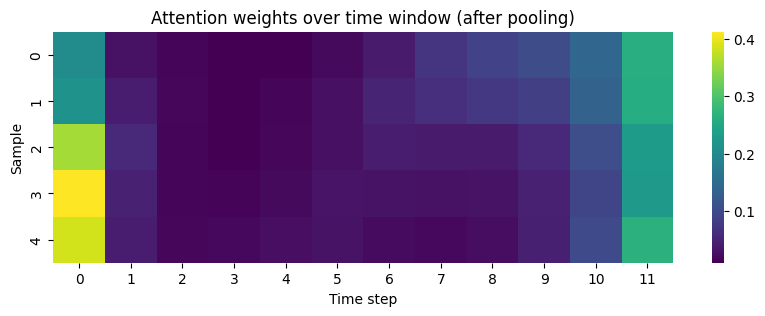

In [28]:
# =========================
# 25. CNN-LSTM + TEMPORAL ATTENTION
# =========================


def build_cnn_lstm_attention(
    input_shape,
    conv_filters=64,
    kernel_size=3,
    lstm_units=64,
    att_units=32,
    dropout=0.2,
):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal")(inputs)
    x = layers.ReLU()(x)
    x = layers.MaxPool1D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)

    # Return full sequences for attention
    x = layers.LSTM(lstm_units, dropout=dropout, return_sequences=True)(x)

    # Additive attention over time
    score = layers.Dense(att_units, activation="tanh")(x)
    score = layers.Dense(1)(score)  # (batch, time, 1)
    att_weights = layers.Softmax(axis=1, name="att_weights")(score)
    # Keras 3: use keras.ops inside the Functional API (tf.reduce_sum breaks on KerasTensor)
    context = keras.ops.sum(att_weights * x, axis=1)  # (batch, lstm_units)

    outputs = layers.Dense(1)(context)

    model = keras.Model(inputs, outputs, name="cnn_lstm_attention")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")

    # Secondary model to extract attention weights for visualization
    att_model = keras.Model(inputs, att_weights, name="cnn_lstm_attention_weights")

    return model, att_model


# Train attention model on the full dataset for one chosen feature variant
ATT_VARIANT = "raw_weather"  # change to "severity_index" if desired

ds = datasets[ATT_VARIANT]
run_name = f"cnn_lstm_attention__{ATT_VARIANT}"

model_att, att_weight_model = build_cnn_lstm_attention(input_shape=ds["X_train_seq"].shape[1:])

print("Training:", run_name)
hist_att = model_att.fit(
    ds["X_train_seq"],
    ds["y_train_seq"],
    validation_data=(ds["X_val_seq"], ds["y_val_seq"]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(run_name),
    verbose=1,
)
TRAINING_HISTORIES[run_name] = hist_att

test_metrics = evaluate_1step_model(
    model=model_att,
    X_seq=ds["X_test_seq"],
    y_seq_scaled=ds["y_test_seq"],
    target_scaler=ds["target_scaler"],
    model_name=run_name,
    batch_size=BATCH_SIZE,
)
test_metrics["split"] = "test"
RESULTS.append(test_metrics)
print("TEST:", {k: test_metrics[k] for k in ["rmse", "mae", "mape", "smape"]})

if SAVE_DIAGNOSTIC_PLOTS:
    save_1step_model_diagnostics(
        run_name, model_att, ds, history=hist_att, batch_size=BATCH_SIZE
    )

# Visualize attention weights for a few test samples
N_SAMPLES = 5
att_w = att_weight_model.predict(ds["X_test_seq"][:N_SAMPLES], verbose=0)  # (n, time, 1)
att_w = att_w.squeeze(-1)

plt.figure(figsize=(10, 3))
sns.heatmap(att_w, cmap="viridis", cbar=True)
plt.title("Attention weights over time window (after pooling)")
plt.xlabel("Time step")
plt.ylabel("Sample")
plt.show()

##### Phase 7: Multi-step (24-hour ahead) forecasting

###### This section switches the target from 1-step to a 24-step horizon using an encoder–decoder LSTM. It reports RMSE per horizon (1..24) and a degradation curve.

In [29]:
# =========================
# 26. MULTI-STEP DATASET (24-step horizon)
# =========================

HORIZON = 24
MULTI_VARIANT = "raw_weather"  # change if desired


def create_sequences_multistep(X, y, window_size=24, horizon=24):
    Xs, ys = [], []
    max_i = len(X) - window_size - horizon
    for i in range(max_i):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size : i + window_size + horizon])
    return np.array(Xs), np.array(ys)


def build_multistep_dataset(feature_cols, window_size=24, horizon=24):
    features_v = df[feature_cols]
    target_v = df[target_col]

    train_size = int(len(df) * 0.70)
    val_size = int(len(df) * 0.15)

    X_train_v = features_v[:train_size]
    y_train_v = target_v[:train_size]

    X_val_v = features_v[train_size : train_size + val_size]
    y_val_v = target_v[train_size : train_size + val_size]

    X_test_v = features_v[train_size + val_size :]
    y_test_v = target_v[train_size + val_size :]

    feature_scaler_v = MinMaxScaler()
    X_train_scaled_v = feature_scaler_v.fit_transform(X_train_v)
    X_val_scaled_v = feature_scaler_v.transform(X_val_v)
    X_test_scaled_v = feature_scaler_v.transform(X_test_v)

    target_scaler_v = MinMaxScaler()
    y_train_scaled_v = target_scaler_v.fit_transform(y_train_v.values.reshape(-1, 1))
    y_val_scaled_v = target_scaler_v.transform(y_val_v.values.reshape(-1, 1))
    y_test_scaled_v = target_scaler_v.transform(y_test_v.values.reshape(-1, 1))

    X_train_seq_v, y_train_seq_v = create_sequences_multistep(X_train_scaled_v, y_train_scaled_v, window_size, horizon)
    X_val_seq_v, y_val_seq_v = create_sequences_multistep(X_val_scaled_v, y_val_scaled_v, window_size, horizon)
    X_test_seq_v, y_test_seq_v = create_sequences_multistep(X_test_scaled_v, y_test_scaled_v, window_size, horizon)

    return {
        "feature_cols": feature_cols,
        "feature_scaler": feature_scaler_v,
        "target_scaler": target_scaler_v,
        "X_train_seq": X_train_seq_v,
        "y_train_seq": y_train_seq_v,
        "X_val_seq": X_val_seq_v,
        "y_val_seq": y_val_seq_v,
        "X_test_seq": X_test_seq_v,
        "y_test_seq": y_test_seq_v,
    }


multi_feature_cols = datasets[MULTI_VARIANT]["feature_cols"]
multistep_ds = build_multistep_dataset(multi_feature_cols, window_size=WINDOW_SIZE, horizon=HORIZON)

print("X_train:", multistep_ds["X_train_seq"].shape)
print("y_train:", multistep_ds["y_train_seq"].shape)
print("X_val  :", multistep_ds["X_val_seq"].shape)
print("y_val  :", multistep_ds["y_val_seq"].shape)
print("X_test :", multistep_ds["X_test_seq"].shape)
print("y_test :", multistep_ds["y_test_seq"].shape)

X_train: (5759, 24, 24)
y_train: (5759, 24, 1)
X_val  : (1196, 24, 24)
y_val  : (1196, 24, 1)
X_test : (1198, 24, 24)
y_test : (1198, 24, 1)


Training: encdec_lstm_24step__raw_weather
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0515 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0405 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0368 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0321 - val_loss: 0.0398 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0279 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0257 - val_loss: 0.0338 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0236 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0221 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0220 - val_loss: 0.0308 -

E0000 00:00:1780409585.073171   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Overall test RMSE: 359.7013724917213


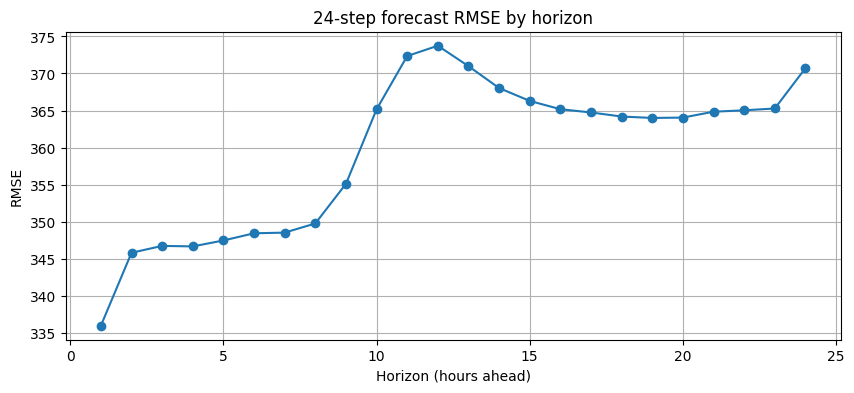

In [30]:
# =========================
# 27. ENCODER–DECODER LSTM (24-step output)
# =========================

# Safe defaults if this cell is run standalone (kernel restart / out-of-order execution)
MULTI_VARIANT = globals().get("MULTI_VARIANT", "raw_weather")
HORIZON = globals().get("HORIZON", 24)

if "multistep_ds" not in globals():
    if "build_multistep_dataset" in globals() and "datasets" in globals():
        multi_feature_cols = datasets[MULTI_VARIANT]["feature_cols"]
        _ws = globals().get("WINDOW_SIZE", 24)
        multistep_ds = build_multistep_dataset(
            multi_feature_cols, window_size=_ws, horizon=HORIZON
        )
    else:
        raise RuntimeError(
            "multistep_ds is not defined. Run cell #26 (MULTI-STEP DATASET) first."
        )


def build_encoder_decoder_lstm(input_shape, horizon=24, enc_units=64, dec_units=64, dropout=0.2):
    enc_inputs = keras.Input(shape=input_shape)
    enc_out, state_h, state_c = layers.LSTM(enc_units, dropout=dropout, return_state=True)(enc_inputs)

    # Repeat encoder context for each future timestep
    x = layers.RepeatVector(horizon)(enc_out)

    # Decoder produces a sequence
    x = layers.LSTM(dec_units, dropout=dropout, return_sequences=True)(x, initial_state=[state_h, state_c])

    outputs = layers.TimeDistributed(layers.Dense(1))(x)  # (batch, horizon, 1)

    model = keras.Model(enc_inputs, outputs, name="encdec_lstm_24step")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


def evaluate_24step(model, X_seq, y_seq_scaled, target_scaler, model_name, batch_size=256):
    y_pred_scaled = model.predict(X_seq, batch_size=batch_size, verbose=0)

    # reshape to (n*horizon, 1) for inverse scaling
    y_true = target_scaler.inverse_transform(y_seq_scaled.reshape(-1, 1)).reshape(-1, HORIZON)
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1, HORIZON)

    rmse_per_h = []
    for h in range(HORIZON):
        rmse_per_h.append(rmse(y_true[:, h], y_pred[:, h]))

    overall_rmse = rmse(y_true.reshape(-1), y_pred.reshape(-1))
    overall_mae = float(mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)))
    overall_r2 = float(r2_score(y_true.reshape(-1), y_pred.reshape(-1)))

    return {
        "model": model_name,
        "task": "24step",
        "split": "test",
        "n_samples": int(len(y_true)),
        "overall_rmse": float(overall_rmse),
        "overall_mae": overall_mae,
        "overall_r2": overall_r2,
        "rmse_per_horizon": rmse_per_h,
    }


run_name = f"encdec_lstm_24step__{MULTI_VARIANT}"
model_24 = build_encoder_decoder_lstm(
    input_shape=multistep_ds["X_train_seq"].shape[1:],
    horizon=HORIZON,
)

print("Training:", run_name)
model_24.fit(
    multistep_ds["X_train_seq"],
    multistep_ds["y_train_seq"],
    validation_data=(multistep_ds["X_val_seq"], multistep_ds["y_val_seq"]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(run_name),
    verbose=1,
)

ms_metrics = evaluate_24step(
    model=model_24,
    X_seq=multistep_ds["X_test_seq"],
    y_seq_scaled=multistep_ds["y_test_seq"],
    target_scaler=multistep_ds["target_scaler"],
    model_name=run_name,
    batch_size=BATCH_SIZE,
)

RESULTS.append(ms_metrics)
print("Overall test RMSE:", ms_metrics["overall_rmse"])

# Horizon degradation curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, HORIZON + 1), ms_metrics["rmse_per_horizon"], marker="o")
plt.title("24-step forecast RMSE by horizon")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

##### Phase 8: Hyperparameter tuning (Keras Tuner)

###### This section is optional if `keras_tuner` is installed. It tunes a CNN-LSTM (you can switch the search space / architecture) and compares the tuned model against the untuned baseline.

In [31]:
# =========================
# 28. KERAS TUNER (optional)
# =========================
# Requires `tensorboard` (Keras Tuner imports it for trial / hparam logging).

try:
    import keras_tuner as kt
except Exception as e:
    kt = None
    print("keras_tuner is not available in this environment:", repr(e))


if kt is not None:
    TUNE_VARIANT = "raw_weather"  # or "severity_index"
    ds = datasets[TUNE_VARIANT]

    def hypermodel(hp):
        conv_filters = hp.Choice("conv_filters", [32, 64, 96])
        kernel_size = hp.Choice("kernel_size", [2, 3, 5])
        lstm_units = hp.Choice("lstm_units", [32, 64, 96])
        dropout = hp.Float("dropout", 0.1, 0.5, step=0.1)
        lr = hp.Choice("lr", [1e-3, 5e-4, 1e-4])

        model = build_cnn_lstm(
            input_shape=ds["X_train_seq"].shape[1:],
            conv_filters=conv_filters,
            kernel_size=kernel_size,
            lstm_units=lstm_units,
            dropout=dropout,
        )
        model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
        return model


    tuner_dir = ARTIFACT_DIR / "tuner"
    tuner = kt.RandomSearch(
        hypermodel,
        objective="val_loss",
        max_trials=10,
        executions_per_trial=1,
        directory=str(tuner_dir),
        project_name=f"cnn_lstm_tune__{TUNE_VARIANT}",
        overwrite=True,
    )

    tuner.search(
        ds["X_train_seq"],
        ds["y_train_seq"],
        validation_data=(ds["X_val_seq"], ds["y_val_seq"]),
        epochs=20,
        batch_size=BATCH_SIZE,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=1,
    )

    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("Best HP:", best_hp.values)

    best_model = tuner.get_best_models(1)[0]
    run_name = f"cnn_lstm_tuned__{TUNE_VARIANT}"

    # Optional: fine-tune best model a bit longer
    best_model.fit(
        ds["X_train_seq"],
        ds["y_train_seq"],
        validation_data=(ds["X_val_seq"], ds["y_val_seq"]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(run_name),
        verbose=1,
    )

    tuned_test = evaluate_1step_model(
        model=best_model,
        X_seq=ds["X_test_seq"],
        y_seq_scaled=ds["y_test_seq"],
        target_scaler=ds["target_scaler"],
        model_name=run_name,
        batch_size=BATCH_SIZE,
    )
    tuned_test["split"] = "test"
    tuned_test["task"] = "1step_tuned"
    tuned_test["best_hp"] = best_hp.values

    RESULTS.append(tuned_test)
    print("TUNED TEST:", {k: tuned_test[k] for k in ["rmse", "mae", "mape", "smape"]})

Trial 10 Complete [00h 00m 08s]
val_loss: 0.02129584737122059

Best val_loss So Far: 0.016107773408293724
Total elapsed time: 00h 01m 12s
Best HP: {'conv_filters': 64, 'kernel_size': 3, 'lstm_units': 96, 'dropout': 0.2, 'lr': 0.0005}
Epoch 1/50


E0000 00:00:1780409658.448148   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0101 - val_loss: 0.0178 - learning_rate: 5.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0095 - val_loss: 0.0162 - learning_rate: 5.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0090 - val_loss: 0.0161 - learning_rate: 5.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0091 - val_loss: 0.0148 - learning_rate: 5.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 0.0153 - learning_rate: 5.0000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0084 - val_loss: 0.0143 - learning_rate: 5.0000e-04
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0083 - val_loss: 0.0150 - learning_rate: 5.0000e-04
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0082 - val_loss: 0.0153 - learning_rate: 5.0000e-04
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0077 - val_loss: 0.0157 - learning_rate: 5.000

E0000 00:00:1780409670.053545   16211 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


##### Final: Aggregate results and write comparison report

###### This cell turns `RESULTS` into a table and writes a detailed comparison report to `model_comparison_report.txt`.

##### Model diagnostics (plots)

Regression models predict **continuous** bike counts, so there is no standard classification confusion matrix. Instead we save:

- **Learning curve** — train vs validation MSE loss per epoch
- **Predicted vs actual** — scatter on val/test (points on the red diagonal = perfect)
- **Residual plot** — error vs predicted value (check bias / heteroscedasticity)
- **Binned confusion matrix** — demand split into 5 quantile bins on **train**; compares predicted bin vs actual bin

Plots are written under `artifacts/plots/{run_name}/` during training. **Confusion matrices** are also saved as JSON under `artifacts/confusion_matrices/{run_name}__{split}.json`, with an index at `artifacts/confusion_matrices/registry.json` for the PDF report. Set `SHOW_DIAGNOSTIC_PLOTS = True` in the metrics cell to also display inline.

In [32]:
# =========================
# 28b. SUMMARY DIAGNOSTIC FIGURES (from TRAINING_HISTORIES)
# =========================

if TRAINING_HISTORIES:
    fig, ax = plt.subplots(figsize=(10, 5))
    for run_name, hist in sorted(TRAINING_HISTORIES.items()):
        if "val_loss" in hist.history:
            ax.plot(hist.history["val_loss"], label=run_name, alpha=0.85)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE loss (scaled target)")
    ax.set_title("Validation loss — all 1-step models trained via train_and_evaluate_1step")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    summary_path = PLOTS_DIR / "summary_val_loss_all_models.png"
    fig.savefig(summary_path, dpi=120, bbox_inches="tight")
    if SHOW_DIAGNOSTIC_PLOTS:
        plt.show()
    else:
        plt.close(fig)
    print("Wrote:", summary_path.resolve())
else:
    print("No TRAINING_HISTORIES yet — run training cells first.")


def reload_and_plot_diagnostics(run_name, ds_key="raw_weather"):
    """Re-generate plots from a saved checkpoint without retraining."""
    path = ARTIFACT_DIR / f"{run_name}.keras"
    if not path.exists():
        print("Missing checkpoint:", path)
        return
    ds = datasets[ds_key]
    m = keras.models.load_model(path)
    save_1step_model_diagnostics(run_name, m, ds, history=None, batch_size=BATCH_SIZE)
    return m


# Example (uncomment after training):
# reload_and_plot_diagnostics("cnn_lstm_tuned__raw_weather")

Wrote: /Users/rohit/Desktop/uni/dl-final-project/artifacts/plots/summary_val_loss_all_models.png


In [33]:
# =========================
# 29. WRITE COMPARISON REPORT (.txt)
# =========================

import json
from datetime import datetime

REPORT_PATH = Path("model_comparison_report.txt")
RESULTS_JSON_PATH = ARTIFACT_DIR / "results.json"


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return None


def _fmt(x, nd=4):
    if x is None:
        return "NA"
    if isinstance(x, (int,)):
        return str(x)
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)


def _results_rows(results):
    rows = []
    for r in results:
        if not isinstance(r, dict):
            continue
        rows.append(r)
    return rows


def _make_1step_table(rows):
    # Keep common 1-step evaluation rows
    out = []
    for r in rows:
        if r.get("task") not in {"1step", "1step_tuned"}:
            continue
        if r.get("split") not in {"val", "test", "test_peak_only", "test_offpeak_only"}:
            continue
        out.append({
            "model": r.get("model"),
            "task": r.get("task"),
            "split": r.get("split"),
            "n_samples": r.get("n_samples"),
            "rmse": _safe_float(r.get("rmse")),
            "mae": _safe_float(r.get("mae")),
            "mape": _safe_float(r.get("mape")),
            "smape": _safe_float(r.get("smape")),
            "r2": _safe_float(r.get("r2")),
            "inference_seconds": _safe_float(r.get("inference_seconds")),
        })
    return out


def _make_multistep_summary(rows):
    for r in rows:
        if r.get("task") == "24step" and r.get("split") == "test":
            return r
    return None


def _render_table(rows, columns):
    # Simple fixed-width text table (no external deps)
    col_widths = {c: len(c) for c in columns}
    for r in rows:
        for c in columns:
            col_widths[c] = max(col_widths[c], len(str(r.get(c, ""))))

    def line(sep="-"):
        return "+" + "+".join(sep * (col_widths[c] + 2) for c in columns) + "+"\

    def row_line(r):
        parts = []
        for c in columns:
            parts.append(f" {str(r.get(c, '')):<{col_widths[c]}} ")
        return "|" + "|".join(parts) + "|"

    s = []
    s.append(line("-"))
    s.append(row_line({c: c for c in columns}))
    s.append(line("="))
    for r in rows:
        s.append(row_line(r))
    s.append(line("-"))
    return "\n".join(s)


rows = _results_rows(RESULTS)

# Persist raw results for reproducibility
RESULTS_JSON_PATH.write_text(json.dumps(rows, indent=2, default=str))

one_step = _make_1step_table(rows)

# Sort: prefer test split, then rmse
one_step_sorted = sorted(
    one_step,
    key=lambda r: (
        0 if r["split"] in {"test", "test_peak_only", "test_offpeak_only"} else 1,
        r["rmse"] if r["rmse"] is not None else 1e18,
    ),
)

# Format values for printing
one_step_print = []
for r in one_step_sorted:
    one_step_print.append({
        "model": r["model"],
        "task": r["task"],
        "split": r["split"],
        "n": r["n_samples"],
        "rmse": _fmt(r["rmse"]),
        "mae": _fmt(r["mae"]),
        "mape": _fmt(r["mape"]),
        "smape": _fmt(r["smape"]),
        "r2": _fmt(r["r2"]),
    })

multi = _make_multistep_summary(rows)

report_lines = []
report_lines.append("Urban Mobility Demand Forecasting — Model Comparison Report")
report_lines.append(f"Generated: {datetime.now().isoformat(timespec='seconds')}")
report_lines.append("")

report_lines.append("## 1-step forecasting (original scale)")
if one_step_print:
    report_lines.append(_render_table(one_step_print, ["model", "task", "split", "n", "rmse", "mae", "r2", "mape", "smape"]))
else:
    report_lines.append("No 1-step results found in RESULTS yet. Run training cells first.")
report_lines.append("")

report_lines.append("## 24-step forecasting")
if multi is None:
    report_lines.append("No 24-step result found in RESULTS yet. Run the multi-step training cell first.")
else:
    report_lines.append(f"Model: {multi.get('model')}")
    report_lines.append(f"Overall RMSE (all horizons flattened): {_fmt(multi.get('overall_rmse'))}")
    report_lines.append(f"Overall MAE (flattened): {_fmt(multi.get('overall_mae'))}")
    report_lines.append(f"Overall R² (flattened): {_fmt(multi.get('overall_r2'))}")
    report_lines.append("RMSE by horizon (1..24):")
    rmse_h = multi.get("rmse_per_horizon", [])
    report_lines.append(", ".join([_fmt(v) for v in rmse_h]))
report_lines.append("")

report_lines.append("## Notes")
report_lines.append("- This is a regression task (predicting continuous bike counts), not classification. There is no \"accuracy\" in the sense of % correct labels; use RMSE/MAE for error and R² for explained variance.")
report_lines.append("- R² closer to 1.0 means the model explains more of the variance in demand on that split; it can go negative if the model is worse than predicting the mean.")
report_lines.append("- All metrics are computed after inverse-scaling predictions back to the original bike-count scale.")
report_lines.append("- MAPE can be unstable near zero counts; sMAPE is included as a more robust alternative.")
report_lines.append("- Peak/off-peak specialist results are evaluated only on their respective test subsets.")

REPORT_PATH.write_text("\n".join(report_lines))
print("Wrote:", REPORT_PATH.resolve())
print("Wrote:", RESULTS_JSON_PATH.resolve())

Wrote: /Users/rohit/Desktop/uni/dl-final-project/model_comparison_report.txt
Wrote: /Users/rohit/Desktop/uni/dl-final-project/artifacts/results.json
